<a href="https://colab.research.google.com/github/DeviSharanyaPasala/Patient-Case-Similarity/blob/main/Patient_Case_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from flask import Flask, request, jsonify

nltk.download("stopwords")

print("Libraries successfully imported")

Libraries successfully imported


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
from google.colab import drive
drive.mount("/content/drive")

# Path to your dataset in Google Drive
file_path = "/content/drive/MyDrive/Patient Case Similarity/SAHeart.csv"

# Load the dataset
df = pd.read_csv(file_path)
print("Dataset loaded successfully")
print("Shape:", df.shape)
print(df.head())

Mounted at /content/drive
Dataset loaded successfully
Shape: (462, 11)
   row.names  sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  \
0          1  160    12.00  5.73      23.11  Present     49    25.30    97.20   
1          2  144     0.01  4.41      28.61   Absent     55    28.87     2.06   
2          3  118     0.08  3.48      32.28  Present     52    29.14     3.81   
3          4  170     7.50  6.41      38.03  Present     51    31.99    24.26   
4          5  134    13.60  3.50      27.78  Present     60    25.99    57.34   

   age  chd  
0   52    1  
1   63    1  
2   46    0  
3   58    1  
4   49    1  


In [3]:
df['famhist'] = df['famhist'].map({'Present': 1, 'Absent': 0})

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values after cleaning:
row.names    0
sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64

Data types:
row.names      int64
sbp            int64
tobacco      float64
ldl          float64
adiposity    float64
famhist        int64
typea          int64
obesity      float64
alcohol      float64
age            int64
chd            int64
dtype: object


In [4]:
def create_case_summary(row):
    return (
        f"Patient aged {row['age']} years with systolic BP {row['sbp']} mmHg, "
        f"LDL cholesterol {row['ldl']} mmol/L, adiposity index {row['adiposity']}, "
        f"Type A behavior score {row['typea']}, obesity level {row['obesity']}, "
        f"alcohol intake {row['alcohol']} L/day, and "
        f"family history of heart disease {'present' if row['famhist']==1 else 'absent'}."
    )

df["medical_note"] = df.apply(create_case_summary, axis=1)

print("Example generated medical note:")
print(df["medical_note"].iloc[0])

Example generated medical note:
Patient aged 52.0 years with systolic BP 160.0 mmHg, LDL cholesterol 5.73 mmol/L, adiposity index 23.11, Type A behavior score 49.0, obesity level 25.3, alcohol intake 97.2 L/day, and family history of heart disease present.


In [5]:
stop_words = set(stopwords.words("english"))
pattern = re.compile(r"[^a-zA-Z0-9\s]")

def clean_text(text):
    text = text.lower()
    text = pattern.sub(" ", text)
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)

df["clean_note"] = df["medical_note"].apply(clean_text)
print("Text cleaning complete")
print("Cleaned example:")
print(df["clean_note"].iloc[0])

Text cleaning complete
Cleaned example:
patient aged 52 0 years systolic bp 160 0 mmhg ldl cholesterol 5 73 mmol l adiposity index 23 11 type behavior score 49 0 obesity level 25 3 alcohol intake 97 2 l day family history heart disease present


In [6]:
vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = vectorizer.fit_transform(df["clean_note"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (462, 187)


In [7]:
cosine_sim = cosine_similarity(tfidf_matrix)
print("Cosine similarity matrix created with shape:", cosine_sim.shape)

# Function to find similar cases
def find_similar_cases(index, top_n=5):
    sim_scores = list(enumerate(cosine_sim[index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    indices = [i[0] for i in sim_scores]
    return df.iloc[indices][["age","sbp","ldl","tobacco","alcohol","chd","medical_note"]]

print("Top 5 cases similar to patient 0:")
display(find_similar_cases(0))

Cosine similarity matrix created with shape: (462, 462)
Top 5 cases similar to patient 0:


,age,sbp,ldl,tobacco,alcohol,chd,medical_note
203,64,128,3.97,0.73,19.20,0,Patient aged 64.0 years with systolic BP 128.0...
371,41,132,5.97,6.00,145.29,0,Patient aged 41.0 years with systolic BP 132.0...
132,30,134,3.73,1.50,11.11,1,Patient aged 30.0 years with systolic BP 134.0...
228,64,138,5.11,2.00,2.06,1,Patient aged 64.0 years with systolic BP 138.0...
198,54,160,9.19,3.00,14.40,1,Patient aged 54.0 years with systolic BP 160.0...


In [8]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
df["cluster"] = kmeans.fit_predict(tfidf_matrix)

silhouette_avg = silhouette_score(tfidf_matrix, df["cluster"])
print("KMeans clustering completed")
print("Cluster distribution:")
print(df["cluster"].value_counts())
print("Silhouette Score:", round(silhouette_avg, 4))

KMeans clustering completed
Cluster distribution:
cluster
0    126
1    116
2    114
3    106
Name: count, dtype: int64
Silhouette Score: 0.0111


In [9]:
X = df[["sbp","tobacco","ldl","adiposity","famhist","typea","obesity","alcohol","age"]]
y = df["chd"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Support Vector Machine": SVC(kernel="rbf", probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

model_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    model_results.append({
        "Model": name,
        "Accuracy": round(acc,4),
        "F1-Score": round(f1,4),
        "AUC": round(auc,4) if auc else "N/A"
    })

results_df = pd.DataFrame(model_results)
print("Model performance comparison:")
print(results_df)

Model performance comparison:
                    Model  Accuracy  F1-Score     AUC
0     Logistic Regression    0.7634    0.6333  0.8006
1  Support Vector Machine    0.6452    0.1081  0.6839
2           Random Forest    0.7097    0.5574  0.7301
3           Decision Tree    0.6022    0.4638  0.5743
4     K-Nearest Neighbors    0.6559    0.3846  0.6261
5       Gradient Boosting    0.7312    0.5763  0.7448


/tmp/ipython-input-3814627490.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=results_df, palette="crest")


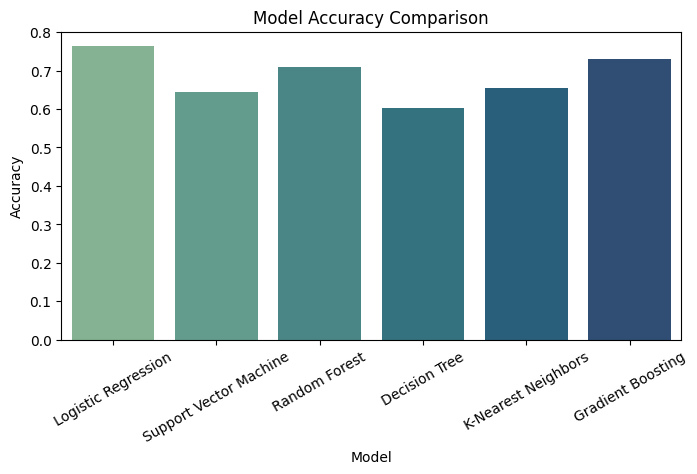

In [10]:
plt.figure(figsize=(8,4))
sns.barplot(x="Model", y="Accuracy", data=results_df, palette="crest")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

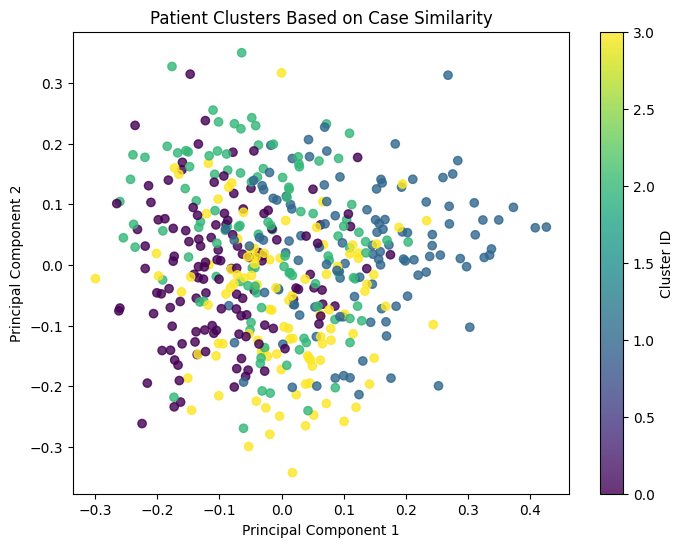

In [11]:
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(8,6))
plt.scatter(reduced_features[:,0], reduced_features[:,1], c=df["cluster"], cmap="viridis", alpha=0.8)
plt.title("Patient Clusters Based on Case Similarity")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster ID")
plt.show()

In [12]:
cluster_summary = df.groupby("cluster")[["age","sbp","ldl","tobacco","alcohol","obesity","typea","chd"]].mean()
print("Cluster Summary (Mean Values per Cluster):")
display(cluster_summary)

global_means = df[["sbp","ldl","tobacco","alcohol","obesity","typea","chd"]].mean()

def interpret_cluster(row):
    risk = []
    if row["chd"] > global_means["chd"]:
        risk.append("High CHD risk")
    if row["sbp"] > global_means["sbp"]:
        risk.append("Elevated blood pressure")
    if row["ldl"] > global_means["ldl"]:
        risk.append("High LDL cholesterol")
    if row["tobacco"] > global_means["tobacco"]:
        risk.append("High tobacco use")
    if row["alcohol"] > global_means["alcohol"]:
        risk.append("Increased alcohol intake")
    if not risk:
        risk.append("Low-risk cluster")
    return ", ".join(risk)

for cid, row in cluster_summary.iterrows():
    print(f"Cluster {cid}: {interpret_cluster(row)}")

Cluster Summary (Mean Values per Cluster):


,age,sbp,ldl,tobacco,alcohol,obesity,typea,chd
cluster,,,,,,,,
0,47.547619,143.865079,5.596190,4.157460,20.082540,28.479444,52.309524,0.380952
1,35.267241,135.017241,3.917155,2.169741,10.440517,23.950431,53.500000,0.275862
2,45.377193,138.622807,4.612632,4.140263,16.570877,25.822456,54.140351,0.429825
3,42.698113,135.047170,4.761132,4.076887,21.169151,25.678868,52.500000,0.292453


Cluster 0: High CHD risk, Elevated blood pressure, High LDL cholesterol, High tobacco use, Increased alcohol intake
Cluster 1: Low-risk cluster
Cluster 2: High CHD risk, Elevated blood pressure, High tobacco use
Cluster 3: High LDL cholesterol, High tobacco use, Increased alcohol intake


In [13]:
app = Flask(__name__)

@app.route("/")
def home():
    return "Patient Case Similarity API is active."

@app.route("/similar", methods=["POST"])
def get_similar():
    data = request.json
    query = data.get("query", "")
    cleaned = re.sub(r'[^a-zA-Z0-9\s]', '', query.lower())
    query_vec = vectorizer.transform([cleaned])
    sim_scores = cosine_similarity(query_vec, tfidf_matrix)[0]
    top_indices = sim_scores.argsort()[-5:][::-1]
    results = df.iloc[top_indices][["age","sbp","ldl","alcohol","medical_note"]].to_dict(orient="records")
    return jsonify(results)

print("Flask API ready. Run with: !python app.py (if saved to file)")

Flask API ready. Run with: !python app.py (if saved to file)
